In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob

In [2]:
logs = glob.glob('/Users/bebr1814/projects/anabaena/scratch_data/training/logs/*.out')
logs

['/Users/bebr1814/projects/anabaena/scratch_data/training/logs/train_cellpose.sbatch_9785569.out',
 '/Users/bebr1814/projects/anabaena/scratch_data/training/logs/train_cellpose.sbatch_9797172.out',
 '/Users/bebr1814/projects/anabaena/scratch_data/training/logs/train_cellpose.sbatch_9781623.out',
 '/Users/bebr1814/projects/anabaena/scratch_data/training/logs/train_cellpose.sbatch_9797182.out',
 '/Users/bebr1814/projects/anabaena/scratch_data/training/logs/train_cellpose.sbatch_9797181.out',
 '/Users/bebr1814/projects/anabaena/scratch_data/training/logs/train_cellpose.sbatch_9775544.out',
 '/Users/bebr1814/projects/anabaena/scratch_data/training/logs/train_cellpose.sbatch_9775524.out',
 '/Users/bebr1814/projects/anabaena/scratch_data/training/logs/train_cellpose.sbatch_9797224.out',
 '/Users/bebr1814/projects/anabaena/scratch_data/training/logs/train_cellpose.sbatch_9781685.out',
 '/Users/bebr1814/projects/anabaena/scratch_data/training/logs/train_cellpose.sbatch_9797171.out']

In [3]:
def read_log(file):
	log = {
		'n_images':0,
		'n_epochs':0,
		'n_train':0,
		'n_test':0,
		'learning_rate':0,
		'weight_decay':0,
		'momentum':0,
		'model_path':'',
		'losses':pd.DataFrame(columns=['epoch', 'train_loss', 'test_loss', 'LR', 'Time']),
	}
	with open(file) as f:
		for line in f:
			if 'images in' in line:
				# 2024-11-07 12:02:46,279 [INFO] 17 / 17 images in /scratch/Shares/anabaena_mcdb6440/fov_images/training_data/ folder have labels
				log['n_images'] = line.split(' ')[3].strip()
			elif 'n_epochs=' in line:
				# 2024-11-07 12:02:57,506 [INFO] >>> n_epochs=500, n_train=16, n_test=None
				stats = line.split('>>> ')[1]
				log['n_epochs'] = stats.split(',')[0].split('=')[1].strip()
				log['n_train'] = stats.split(',')[1].split('=')[1].strip()
				log['n_test'] = stats.split(',')[2].split('=')[1].strip()
			elif "learning_rate=" in line:
				# 2024-11-07 12:02:57,508 [INFO] >>> SGD, learning_rate=0.00001, weight_decay=0.00010, momentum=0.900
				stats = line.split('>>> ')[1]
				log['learning_rate'] = stats.split(',')[1].split('=')[1].strip()
				log['weight_decay'] = stats.split(',')[2].split('=')[1].strip()
				log['momentum'] = stats.split(',')[3].split('=')[1].strip()
			elif 'saving model to' in line:
				# 2024-11-07 12:03:12,116 [INFO] >>> saving model to /scratch/Shares/anabaena_mcdb6440/fov_images/training_data/models/cellpose_1731006192.111924
				log['model_path'] = line.split(' ')[-1].strip()
			elif 'train_loss=' in line:
				# 2024-11-07 12:03:18,182 [INFO] 0, train_loss=0.6014, test_loss=0.0000, LR=0.0000, time 6.07s
				# 2024-11-07 12:03:22,627 [INFO] 5, train_loss=0.5768, test_loss=0.0000, LR=0.0000, time 10.52s
				# 2024-11-07 12:03:26,887 [INFO] 10, train_loss=0.5414, test_loss=0.0000, LR=0.0000, time 14.78s
				info = line.split('[INFO] ')[1]
				epoch = int(info.split(',')[0].strip())
				train_loss = float(info.split(',')[1].split('=')[1].strip())
				test_loss = float(info.split(',')[2].split('=')[1].strip())
				lr = float(info.split(',')[3].split('=')[1].strip())
				time = float(info.split(',')[4].split(' ')[2].strip().replace('s',''))
				log['losses'] = pd.concat([log['losses'], pd.DataFrame([[epoch, train_loss, test_loss, lr, time]], columns=['epoch', 'train_loss', 'test_loss', 'LR', 'Time'])])

	return log

In [4]:
# Plot train loss curve
def plot_loss_curve(log):
	fig, ax = plt.subplots()
	ax.plot(log['losses']['epoch'], log['losses']['train_loss'], label='train loss')
	ax.plot(log['losses']['epoch'], log['losses']['test_loss'], label='test loss')
	ax.set_xlabel('Epoch')
	ax.set_ylabel('Loss')
	ax.set_title('Loss curve')
	ax.legend()
	plt.show()



/tmp/ipykernel_38842/1485641724.py:43: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  log['losses'] = pd.concat([log['losses'], pd.DataFrame([[epoch, train_loss, test_loss, lr, time]], columns=['epoch', 'train_loss', 'test_loss', 'LR', 'Time'])])


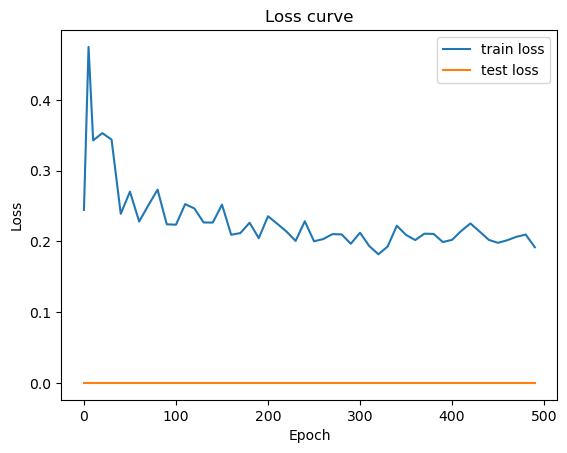

In [5]:
log = read_log('/Users/bebr1814/projects/anabaena/scratch_data/training/logs/train_cellpose.sbatch_9797224.out')
plot_loss_curve(log)


/tmp/ipykernel_46124/1485641724.py:43: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  log['losses'] = pd.concat([log['losses'], pd.DataFrame([[epoch, train_loss, test_loss, lr, time]], columns=['epoch', 'train_loss', 'test_loss', 'LR', 'Time'])])
/tmp/ipykernel_46124/1485641724.py:43: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  log['losses'] = pd.concat([log['losses'], pd.DataFrame([[epoch, train_loss, test_loss, lr, time]], columns=['epoch', 'train_loss', 'test_loss', 'LR', 'Time'])])
/tmp/ipy

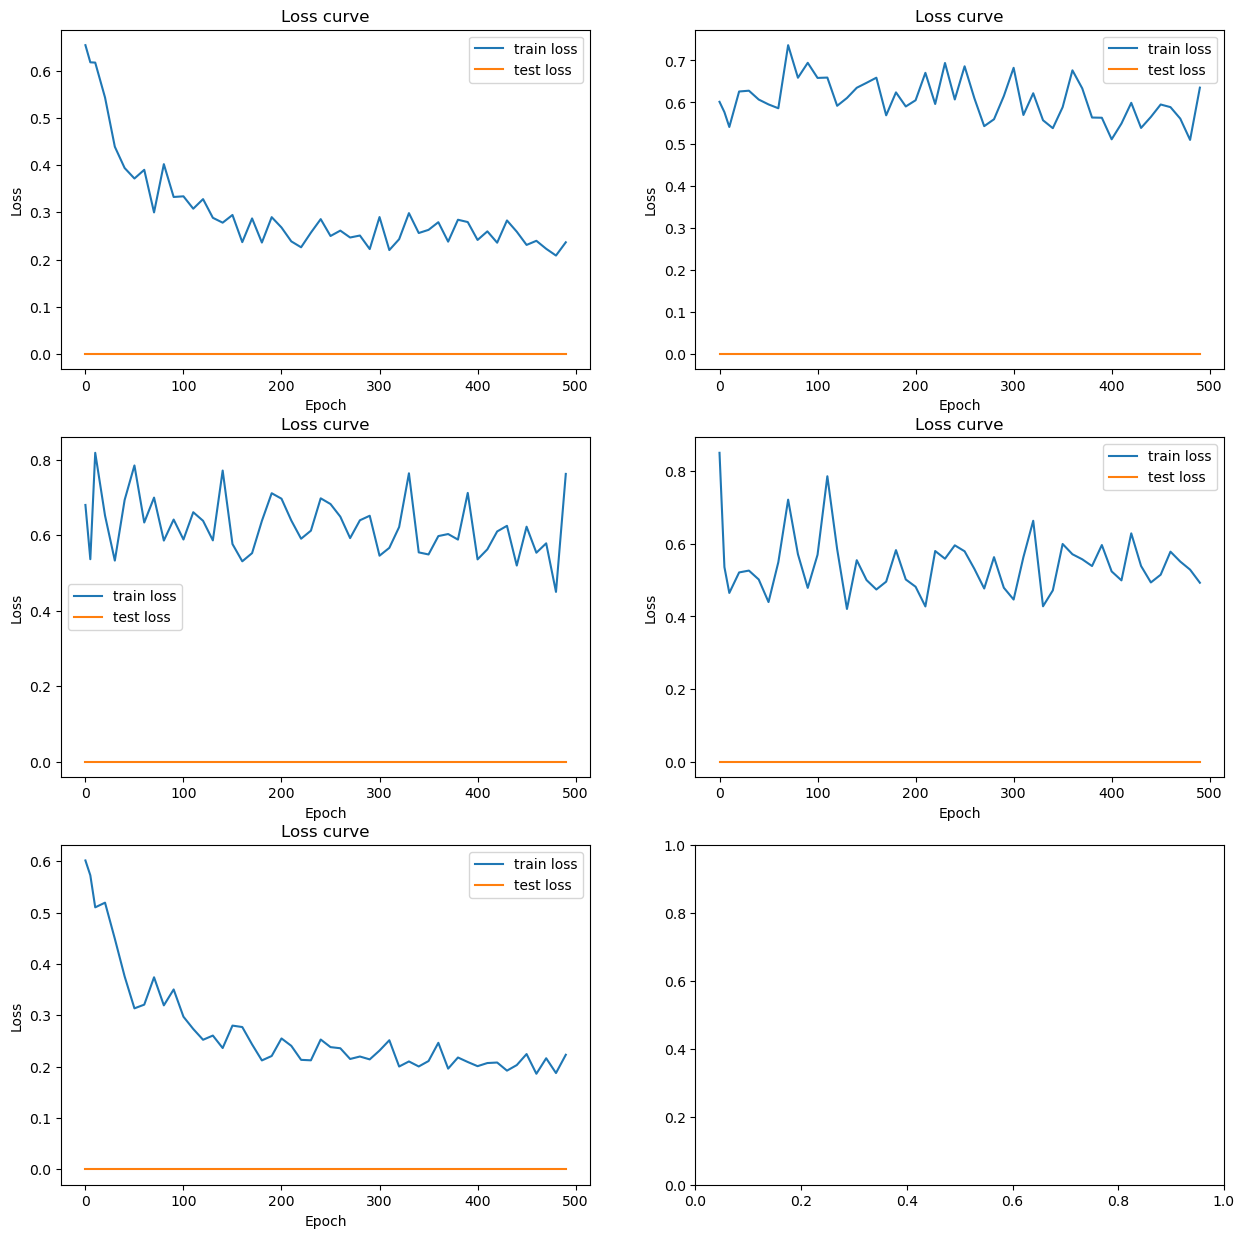

In [6]:
# plot a grid of curves for all logs

n = len(logs)
cols = 2
rows = n // cols + 1
fig, axs = plt.subplots(rows, cols, figsize=(15, 5*rows))

for i, log in enumerate(logs):
	ax = axs[i//cols, i%cols]
	log = read_log(log)
	ax.plot(log['losses']['epoch'], log['losses']['train_loss'], label='train loss')
	ax.plot(log['losses']['epoch'], log['losses']['test_loss'], label='test loss')
	ax.set_xlabel('Epoch')
	ax.set_ylabel('Loss')
	ax.set_title('Loss curve')
	ax.legend()
plt.show()
